## 2D CSA
Seperate plot for each host, then we combine the outcomes

In [63]:
import numpy as np
import matplotlib.pyplot as plt

In [64]:
# np.random.seed(42)

### Parameters

In [65]:
n_phages = 800
n_hosts = 5
n_predictors_per_host = 2   
alpha = 0.1
M = 300

### Generating the directions

In [66]:
def generate_directions(dim, M):
    """
    generates the projection directions, we map our scores to these directions to get half spaces
    """
    # Generating M random vectors in a K-dimensional space.
    V = np.random.normal(size=(M, dim)) 

    # making sure that the projection directions are only in the the positive axes
    U = np.abs(V)    
    
    # Normalizeing each vector to unit length
    U /= np.linalg.norm(U, axis=1, keepdims=True)

    return U

### Score Vector

In [67]:
def score_vector(probabilities, y):
    """
    Calculates the 'Non-Conformity Score'.
    If y=1 but probability is low, the score is high (bad fit).
    If y=0 but probability is high, the score is high (predictor is a bad fit).
    Lower scores mean the data 'conforms' better to the model's expectations.
    """
    return np.where(y == 1, 1 - probabilities, probabilities)

### CSA for 1 Host

In [68]:
def csa_per_host(host_id, predictions, Y, alpha_joint, n_hosts, n_predictors_per_host, M):
    """
    It defines the boundary (envelope) of 'normal' errors for a specific host.
    """
    # If we want 90% confidence across 5 hosts, we need higher confidence for each individual host to account for multiple comparisons.
    alpha = alpha_joint / n_hosts 

    print(f"\nCALIBRATING HOST {host_id} (Individual Target Error Rate α_h: {alpha:.4f})")
    
    probs = predictions[:, host_id, :]
    labels = Y[:, host_id]

    # Converting the probabilities into score vectors 
    scores = score_vector(probs, labels[:, np.newaxis])
    
    
    ######### Splitting the data ########
    # S1 (Shape): Used to find the shape of the envelope
    # S2 (Size): Used to scale that region so it captures exactly (1-alpha) of data.
    perm = np.random.permutation(len(scores))
    n1 = len(scores) // 2
    S1, S2 = scores[perm[:n1]], scores[perm[n1:]]

    # Generating M directions in the score space
    U = generate_directions(n_predictors_per_host, M)

    ######### Shape Discovery #########
    # projecting our known errors (S1) onto our directions (U).
    projections_S1 = S1 @ U.T 
    
    # Testing different beta values for our directions, to get the max beta value.
    beta_candidates = np.sort(np.linspace(alpha/M, alpha, 100))[::-1]
    
    q_tilde = None
    for beta in beta_candidates:
        # Calculating the directional quantile for every direction at this beta
        q_beta = np.percentile(projections_S1, (1 - beta) * 100, axis=0)
        
        # Checking a point is inside the intersection of all these half-planes
        inside = np.all(projections_S1 <= q_beta, axis=1)
        
        # if the current combination actually is covering 1-alpha of the data then this is the shape of out envelope
        if np.mean(inside) >= 1 - alpha:
            q_tilde = q_beta
            print(f"Shape Found: β*: {beta:.6f} | Training Coverage: {np.mean(inside):.4f}")
            break
    
    # If in case no beta satisfies our condition
    if q_tilde is None: 
        q_tilde = np.percentile(projections_S1, (1 - alpha/M) * 100, axis=0)

    ######## Size Scaling ########
    # testing how well our shape fits the second set of data (S2).
    projections_S2 = S2 @ U.T
    
    # For every point in S2, we find the factor 't' needed to stretch the q_tilde envelope so that the point is inside.
    t_stars = np.max(projections_S2 / (q_tilde + 1e-12), axis=1) 
    
    # We take the (1-alpha) quantile of these t stars.
    # This 't_hat' ensures that the envelope is sized correctly for unseen data.
    sorted_tau = np.sort(t_stars)
    idx = int(np.ceil((len(t_stars) + 1) * (1 - alpha))) - 1

    # Final scalar quantile that provides the 1-alpha coverage guarantee
    t_hat = sorted_tau[np.clip(idx, 0, len(t_stars) - 1)]
    print(f"Calibration Complete: Scaling factor hat_t: {t_hat:.4f}")

    # the final threshold for every direction that defines the 'Valid' region
    q_final = q_tilde * t_hat
    # Return calibration points, directions, and envelope thresholds
    return S1, U, q_final

### Execution

#### Generating the Data

In [69]:
# Generating true y label values using binomial distribution with 40% infection probability
Y = np.random.binomial(1, 0.4, (n_phages, n_hosts))

# Generating the predictions
predictions = np.zeros((n_phages, n_hosts, n_predictors_per_host))   # array to store predictions from multiple models
for h in range(n_hosts):
    for f in range(n_predictors_per_host):
        # generating noise with beta distribution
        noise = np.random.beta(3, 2, n_phages)
        # generating predictions (leans 60% on truth and 40% on random noise)
        predictions[:, h, f] = np.clip(0.6 * Y[:, h] + 0.4 * noise, 0.01, 0.99)

#### Testing a new phage

In [70]:
# generating the true (hidden) for one phage across all hosts (represents the actual infection statis we are trying to predict)
test_label = np.random.binomial(1, 0.4, n_hosts)    

# matrix to store new observations from the models
test_probs = np.zeros((n_hosts, n_predictors_per_host))  

# for each host each of the predictors provide a probability score
for h in range(n_hosts):
    # adding noise to the new prediction - prediction doesnt see the test label only the noise does
    noise = np.random.beta(3, 2, n_predictors_per_host)
    # constructing the test probabilities similar to the calibration data
    test_probs[h] = np.clip(0.6 * test_label[h] + 0.4 * noise, 0.01, 0.99)

# Displaying the true labels
print(f"Ground Truth Infection Profile: {test_label}")

Ground Truth Infection Profile: [1 0 1 1 0]


#### Predicting and Plotting for each Host


CALIBRATING HOST 0 (Individual Target Error Rate α_h: 0.0200)
Shape Found: β*: 0.004899 | Training Coverage: 0.9800
Calibration Complete: Scaling factor hat_t: 1.0054

CALIBRATING HOST 1 (Individual Target Error Rate α_h: 0.0200)
Shape Found: β*: 0.007516 | Training Coverage: 0.9800
Calibration Complete: Scaling factor hat_t: 1.0068

CALIBRATING HOST 2 (Individual Target Error Rate α_h: 0.0200)
Shape Found: β*: 0.004899 | Training Coverage: 0.9875
Calibration Complete: Scaling factor hat_t: 1.0131

CALIBRATING HOST 3 (Individual Target Error Rate α_h: 0.0200)
Shape Found: β*: 0.004899 | Training Coverage: 0.9800
Calibration Complete: Scaling factor hat_t: 0.9860

CALIBRATING HOST 4 (Individual Target Error Rate α_h: 0.0200)
Shape Found: β*: 0.004899 | Training Coverage: 0.9825
Calibration Complete: Scaling factor hat_t: 1.0168


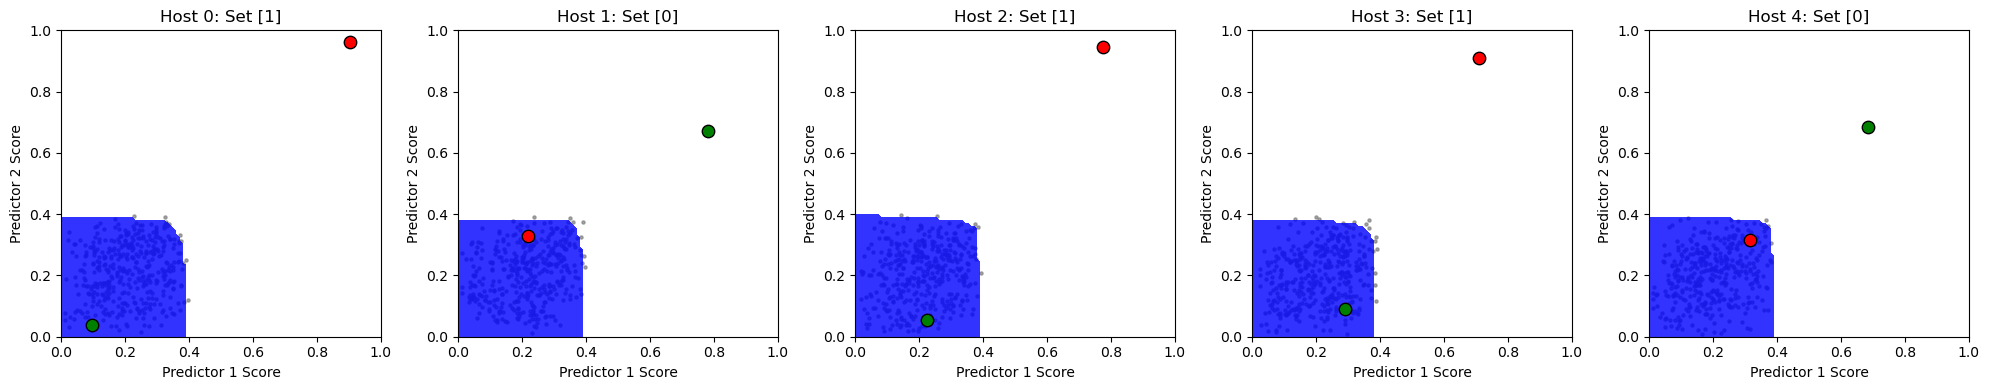

In [71]:
fig, axes = plt.subplots(1, n_hosts, figsize=(4 * n_hosts, 4))   # subplots - one for each host

for h in range(n_hosts):
    # For each host we run CSA to get S1, U and calibration thresholds
    S1, U, q_final = csa_per_host(h, predictions, Y, alpha, n_hosts, n_predictors_per_host, M)
    ax = axes[h]

    # Plotting the calibration data
    ax.scatter(S1[:, 0], S1[:, 1], alpha=0.7, s=5, color='gray', label="S1")

    # Plotting the envelope
    grid_x = np.linspace(0, 1, 100)
    X, Yg = np.meshgrid(grid_x, grid_x)
    grid = np.stack([X.ravel(), Yg.ravel()], axis=1)

    # a point is inside only id its projection onto all the directions is less than q_final
    inside = np.all(grid @ U.T <= q_final, axis=1).reshape(X.shape)
    ax.contourf(X, Yg, inside, levels=[0.5, 1], alpha=0.8, colors='blue')

    # Testing the new phage (two hypothesis) 
    # s1: "If the truth is Infection (Y=1)?" -> Score = 1 - probability
    # s0: "If the truth is No Infection (Y=0)?" -> Score = probability
    p_host = test_probs[h]
    s1 = 1 - p_host
    s0 = p_host

    # Checking if the score vector is inside the calibrated envelope
    in1 = np.all(s1 @ U.T <= q_final)
    in0 = np.all(s0 @ U.T <= q_final)
    
    # Building the prediction set - if the hypothesis is inside the envelope, we do not reject it
    p_set = [val for val, inside in [(0, in0), (1, in1)] if inside]

    # Plotting the scores (green for y=1 and red for y = 0)
    ax.scatter(*s1, color="green", s=80, edgecolors='black', label="s(x,1)")
    ax.scatter(*s0, color="red", s=80, edgecolors='black', label="s(x,0)")
    
    ax.set_title(f"Host {h}: Set {p_set}")
    ax.set_xlabel("Predictor 1 Score")
    ax.set_ylabel("Predictor 2 Score")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()